## Demo Notebook: Transfer Learning for Vision

This demo uses a real image task where where we train a simple CNN from scratch: distinguishing cats from dogs using a small subset of CIFAR-10.

This is a stronger teaching demo than a toy synthetic example because the representation problem is obvious: raw pixels are hard to model directly, while a pretrained vision encoder already captures useful visual patterns. we had to keep the model simple, as the larger/deeper you go the more computation requirement is needed!

In [71]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Defining hardware

This first bit, involves defining what tool we are going to use to train the model and what our training split will be.

In [72]:
split_ratio = 0.7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## Creating our dataset

For this part we are going to reduce the number of labels that we want, as the orginal dataset has 10 classes. After this we are just defining our train/val/test splits of our data.

In [73]:
CLASS_IDS = [3, 5]  # CIFAR-10: cat, dog
CLASS_NAMES = {3: 'cat', 5: 'dog'}
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 200

base_train = torchvision.datasets.CIFAR10(root='data', train=True, download=True, transform=transforms.ToTensor())
base_test = torchvision.datasets.CIFAR10(root='data', train=False, download=True, transform=transforms.ToTensor())

def select_indices(targets, class_ids, max_per_class):
    counts = {class_id: 0 for class_id in class_ids}
    selected = []
    for idx, label in enumerate(targets):
        if label in counts and counts[label] < max_per_class:
            selected.append(idx)
            counts[label] += 1
        if all(count == max_per_class for count in counts.values()):
            break
    return selected

data_idx = select_indices(base_train.targets, CLASS_IDS, TRAIN_PER_CLASS)
test_idx = select_indices(base_test.targets, CLASS_IDS, TEST_PER_CLASS)

data_idx = shuffle(data_idx)

train_idx = data_idx[:int(len(data_idx)*split_ratio)]
val_idx = data_idx[int(len(data_idx)*split_ratio):]

print('Training images:', len(train_idx))
print('validation images:', len(val_idx))
print('Test images:', len(test_idx))


Files already downloaded and verified


/home/vgv/anaconda3/envs/aaib26/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Training images: 700
validation images: 300
Test images: 400


## Exploring some samples

Lets plot a few of our images, just to make sure that we are actually exploring images with the correct labels

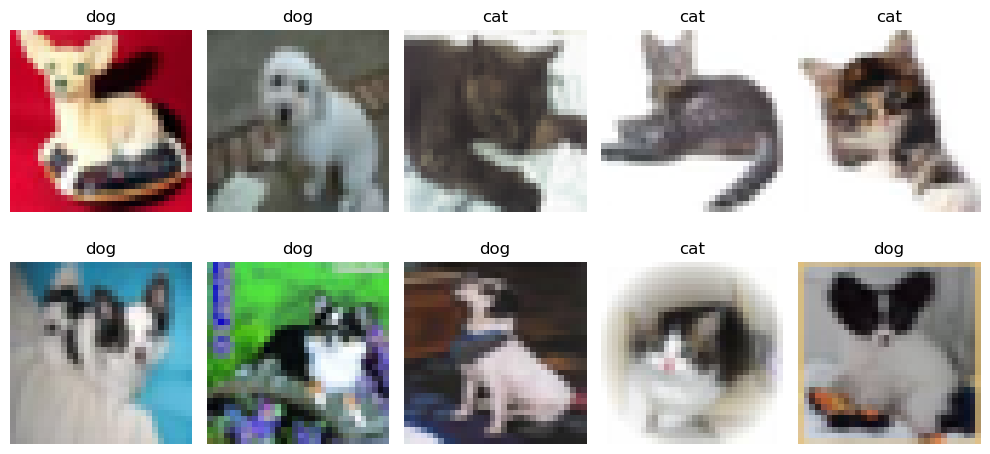

In [74]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), train_idx[:10]):
    image, label = base_train[idx]
    image = image.detach().numpy()
    image = np.transpose(image, (1, 2, 0))
    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Creating the dataloader

For this part we are simiply defining our dataloader, which is how the samples are going to read into the model.

In [75]:
class FilteredCIFAR10(Dataset):
    def __init__(self, base_dataset, indices, class_ids):
        self.base_dataset = base_dataset
        self.indices = indices
        self.class_ids = class_ids

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        label = 0 if label == self.class_ids[0] else 1
        return image, label

train_dataset = FilteredCIFAR10(base_train, train_idx, CLASS_IDS)
val_dataset = FilteredCIFAR10(base_train, val_idx, CLASS_IDS)
test_dataset = FilteredCIFAR10(base_test, test_idx, CLASS_IDS)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

## Building the model

Here we are going the use pytorch's "Sequential" function to configure our model

In [76]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cnnmodel = nn.Sequential(
            nn.Conv2d(3, 6, 5), # Convolution layer
            nn.ReLU(),          # Activation function
            nn.AvgPool2d(2, 2), # Pooling layer
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.AvgPool2d(2, 2)
        )
        self.fullyconn = nn.Sequential(
            nn.Linear(400, 120), # Linear Layer
            nn.ReLU(),           # ReLU Activation Function
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 2)
        )

    def forward(self, x):
        x = self.cnnmodel(x)
        x = x.view(x.size(0), -1)
        x = self.fullyconn(x)
        return x

## Calling our model and other aspects

In this part we call our model and then also define things like learning rate, loss function, optimiser and schedular

In [77]:
mymodel = LeNet().to(device) # Move the model to GPU if available
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mymodel.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

## Our training loop

Here we just use a simple training loop, were for every epoch we rotate through the training data and then validation

0
Total number of samples 300 and 133 correct
1
Total number of samples 300 and 139 correct
2
Total number of samples 300 and 172 correct
3
Total number of samples 300 and 173 correct
4
Total number of samples 300 and 169 correct
5
Total number of samples 300 and 174 correct
6
Total number of samples 300 and 172 correct
7
Total number of samples 300 and 174 correct
8
Total number of samples 300 and 179 correct
9
Total number of samples 300 and 178 correct
10
Total number of samples 300 and 180 correct
11
Total number of samples 300 and 180 correct
12
Total number of samples 300 and 178 correct
13
Total number of samples 300 and 175 correct
14
Total number of samples 300 and 164 correct
15
Total number of samples 300 and 170 correct
16
Total number of samples 300 and 165 correct
17
Total number of samples 300 and 166 correct
18
Total number of samples 300 and 183 correct
19
Total number of samples 300 and 171 correct
20
Total number of samples 300 and 176 correct
21
Total number of samp

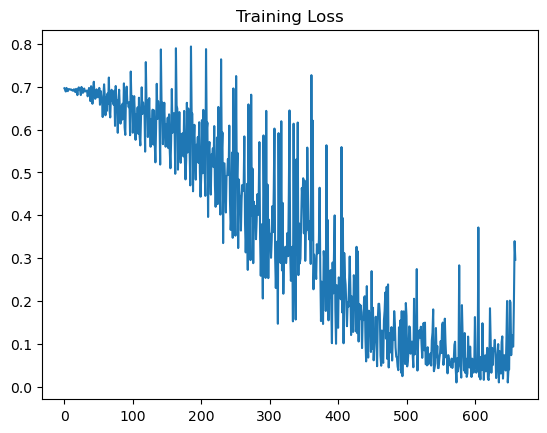

In [78]:
loss_arr = []
var_arr = []
val_acc = []
for epoch in range(30):
    print(epoch)
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        ypred = mymodel(images)
        
        loss = loss_fn(ypred, labels)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_arr.append(loss.item())
        correct = 0
        total = 0
        mymodel.eval()
        # since we're not training, we don't need to calculate the gradients for our outputs
        with torch.no_grad(): ## cal accuracy
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                # calculate outputs by running images through the network
                outputs = mymodel(images)
                _, predicted = torch.max(outputs, 1) # find predicted class
                
                total += labels.size(0) 
                correct += (predicted == labels).sum().item() #sum to find accuracy
    val_acc.append(correct)
    print("Total number of samples {} and {} correct".format(total, correct))
               
                
plt.plot(loss_arr)
plt.title('Training Loss')
plt.show()

## To test our model

As the model has seen both our training and validation sets, its important that we test it on something it hasnt seen. This is where our test set comes into it.

In [79]:
correct = 0
total = 0
labs = []
pred = []
mymodel.eval()
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad(): ## cal accuracy
    for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            # calculate outputs by running images through the network
            outputs = mymodel(images)
            _, predicted = torch.max(outputs, 1) # find predicted class
            labs.append(labels.detach().cpu().numpy())
            pred.append(predicted.detach().cpu().numpy())
            total += labels.size(0) 
            correct += (predicted == labels).sum().item() #sum to find accuracy
    print("Total number of samples {} and {} correct".format(total, correct))

Total number of samples 400 and 229 correct


Classification report for pretrained features:
              precision    recall  f1-score   support

         cat       0.56      0.72      0.63       200
         dog       0.60      0.42      0.50       200

    accuracy                           0.57       400
   macro avg       0.58      0.57      0.56       400
weighted avg       0.58      0.57      0.56       400



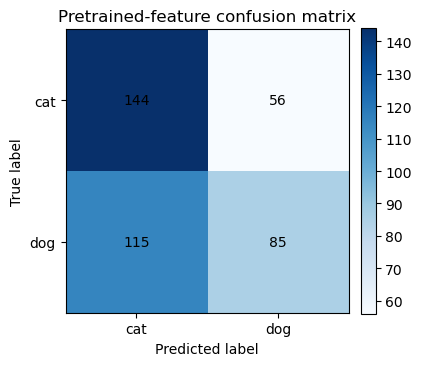

In [80]:
print('Classification report for pretrained features:')
print(classification_report(labs, pred, target_names=['cat', 'dog']))

cm = confusion_matrix(labs, pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['cat', 'dog'])
ax.set_yticklabels(['cat', 'dog'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Pretrained-feature confusion matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()